# Лабораторная работа №4: Диффузионные модели

## Цель
Изучить принципы работы диффузионных моделей на примере Stable Diffusion и DDPM, научиться управлять процессом генерации.

## Теория
- Прямой и обратный процесс в диффузионных моделях.
- Отличие DDPM от GAN.
- Stable Diffusion и использование текстовых эмбеддингов.

## Задания
Часть 1. Stable Diffusion:
1. Использовать предобученную модель (HuggingFace diffusers).
2. Сгенерировать изображения по разным промптам.
3. Исследовать влияние параметров (guidance scale, количество шагов).

Часть 2. DDPM:
1. Реализовать упрощённый DDPM (по готовому туториалу).
2. Обучить модель на MNIST или CIFAR-10.
3. Визуализировать процесс: добавление шума и восстановление.

## Вопросы
1. Чем диффузионные модели отличаются от GAN?
2. Почему количество шагов важно для качества?
3. Какие ещё задачи (помимо генерации картинок) можно решать диффузионными моделями?


## Отчёт
- Иллюстрации сгенерированных изображений.
- Графики/визуализации процесса диффузии.
- Ответы на вопросы.

In [ ]:
# Установка необходимых библиотек
!pip install diffusers transformers accelerate torch torchvision matplotlib tqdm

## Часть 1. Stable Diffusion

In [ ]:
import torch
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Загрузка модели Stable Diffusion v1-5
try:
    model_id = "runwayml/stable-diffusion-v1-5"
    pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16 if device=="cuda" else torch.float32)
    pipe = pipe.to(device)
except Exception as e:
    print(f"Error loading model: {e}. Check internet connection or disk space.")

def show_images(images, title=""):
    fig, axs = plt.subplots(1, len(images), figsize=(15, 5))
    if len(images) == 1: axs = [axs]
    for i, img in enumerate(images):
        axs[i].imshow(img)
        axs[i].axis('off')
    plt.suptitle(title)
    plt.show()

Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

...

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Generating: a futuristic city with flying cars, cyberpunk style


  0%|          | 0/50 [00:00<?, ?it/s]

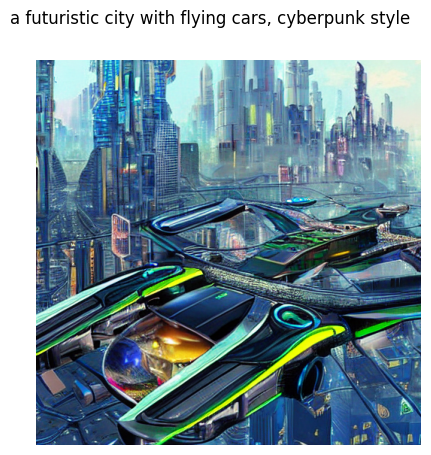

Generating: an oil painting of a cottage by the river in autumn


  0%|          | 0/50 [00:00<?, ?it/s]

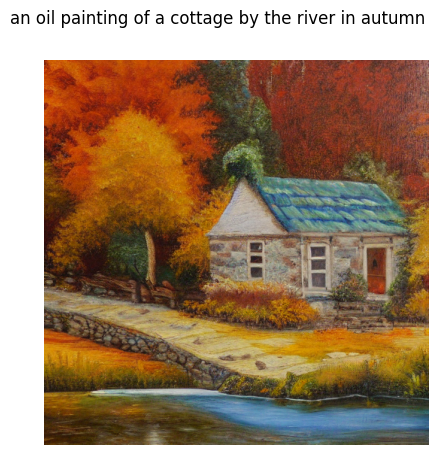

In [ ]:
# Генерация изображений по разным промптам
prompts = [
    "a futuristic city with flying cars, cyberpunk style",
    "an oil painting of a cottage by the river in autumn"
]

if 'pipe' in locals():
    for p in prompts:
        print(f"Generating: {p}")
        image = pipe(p).images[0]
        show_images([image], title=p)

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

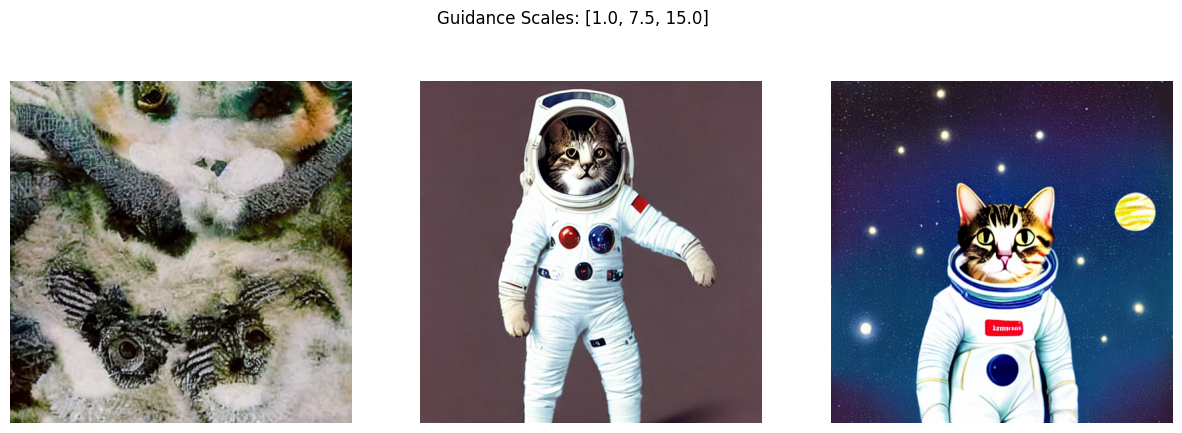

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

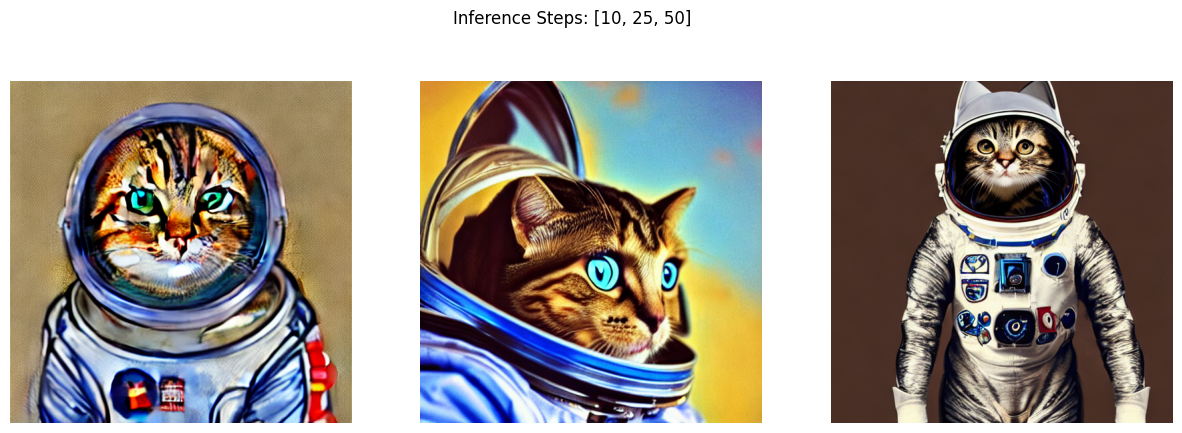

In [ ]:
# 3. Исследование влияния параметров
base_prompt = "a portrait of a cat wearing a space suit"

if 'pipe' in locals():
    # Влияние Guidance Scale
    scales = [1.0, 7.5, 15.0]
    scale_images = []
    for s in scales:
        img = pipe(base_prompt, guidance_scale=s).images[0]
        scale_images.append(img)
    show_images(scale_images, title=f"Guidance Scales: {scales}")

    # Влияние количества шагов (Steps)
    steps = [10, 25, 50]
    step_images = []
    for s in steps:
        img = pipe(base_prompt, num_inference_steps=s).images[0]
        step_images.append(img)
    show_images(step_images, title=f"Inference Steps: {steps}")

## Часть 2. DDPM (Simplified)
Реализация упрощенной диффузионной модели на MNIST.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# Гиперпараметры
n_T = 400 # количество шагов диффузии
n_classes = 10
n_feat = 128 # размерность скрытого слоя
l_rate = 1e-4
batch_size = 128
img_size = 28

class ResidualConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, is_res=False):
        super().__init__()
        self.same_channels = in_channels==out_channels
        self.is_res = is_res
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 1, 1),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),
            nn.Conv2d(out_channels, out_channels, 3, 1, 1),
            nn.BatchNorm2d(out_channels),
            nn.GELU(),
        )
    def forward(self, x):
        if self.is_res:
            x1 = self.conv1(x)
            if self.same_channels:
                out = x + x1
            else:
                out = x1
            return out / 1.414
        else:
            return self.conv1(x)

class UnetDown(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(UnetDown, self).__init__()
        self.layers = nn.Sequential(
            ResidualConvBlock(in_channels, out_channels),
            nn.MaxPool2d(2)
        )
    def forward(self, x):
        return self.layers(x)

class UnetUp(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(UnetUp, self).__init__()
        self.layers = nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, 2, 2),
            ResidualConvBlock(out_channels, out_channels),
            ResidualConvBlock(out_channels, out_channels)
        )
    def forward(self, x, skip):
        x = torch.cat((x, skip), 1)
        return self.layers(x)

class EmbedFC(nn.Module):
    def __init__(self, input_dim, emb_dim):
        super(EmbedFC, self).__init__()
        self.input_dim = input_dim
        self.layers = nn.Sequential(
            nn.Linear(input_dim, emb_dim),
            nn.GELU(),
            nn.Linear(emb_dim, emb_dim),
        )
    def forward(self, x):
        x = x.view(-1, self.input_dim)
        return self.layers(x)

class ContextUnet(nn.Module):
    def __init__(self, in_channels, n_feat=256, n_classes=10):
        super(ContextUnet, self).__init__()
        self.in_channels = in_channels
        self.n_feat = n_feat
        self.n_classes = n_classes

        self.init_conv = ResidualConvBlock(in_channels, n_feat, is_res=True)

        self.down1 = UnetDown(n_feat, n_feat)
        self.down2 = UnetDown(n_feat, 2 * n_feat)

        self.to_vec = nn.Sequential(nn.AvgPool2d(7), nn.GELU())

        self.timeembed1 = EmbedFC(1, 2*n_feat)
        self.timeembed2 = EmbedFC(1, 1*n_feat)
        self.contextembed1 = EmbedFC(n_classes, 2*n_feat)
        self.contextembed2 = EmbedFC(n_classes, 1*n_feat)

        self.up0 = nn.Sequential(
            nn.ConvTranspose2d(2 * n_feat, 2 * n_feat, 7, 7),
            nn.GroupNorm(8, 2 * n_feat),
            nn.ReLU(),
        )

        self.up1 = UnetUp(4 * n_feat, n_feat)
        self.up2 = UnetUp(2 * n_feat, n_feat)
        self.out = nn.Sequential(
            nn.Conv2d(2 * n_feat, n_feat, 3, 1, 1),
            nn.GroupNorm(8, n_feat),
            nn.ReLU(),
            nn.Conv2d(n_feat, in_channels, 3, 1, 1),
        )

    def forward(self, x, c, t, context_mask):
        x = self.init_conv(x)
        down1 = self.down1(x)
        down2 = self.down2(down1)
        hiddenvec = self.to_vec(down2)

        c = c * context_mask
        cemb1 = self.contextembed1(c).view(-1, self.n_feat * 2, 1, 1)
        temb1 = self.timeembed1(t).view(-1, self.n_feat * 2, 1, 1)
        cemb2 = self.contextembed2(c).view(-1, self.n_feat, 1, 1)
        temb2 = self.timeembed2(t).view(-1, self.n_feat, 1, 1)

        up1 = self.up0(hiddenvec)
        up2 = self.up1(cemb1*up1 + temb1, down2)
        up3 = self.up2(cemb2*up2 + temb2, down1)
        out = self.out(torch.cat((up3, x), 1))
        return out


In [ ]:
# Init Model & Data
ddpm = ContextUnet(in_channels=1, n_feat=n_feat, n_classes=n_classes).to(device)
dataset = datasets.MNIST("./data", train=True, download=True, transform=transforms.ToTensor())
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)
optim = torch.optim.Adam(ddpm.parameters(), lr=l_rate)

# DDPM Constants
beta1, beta2 = 1e-4, 0.02
beta_t = (beta2 - beta1) * torch.arange(0, n_T + 1).to(device) / n_T + beta1
alphabar_t = torch.cumsum(torch.log(1 - beta_t), dim=0).exp()

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 413kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.31MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.5MB/s]


In [ ]:
# Training Loop
print("Starting training")
for ep in range(3): # Train for 3 epochs 
    ddpm.train()
    optim.param_groups[0]['lr'] = l_rate * (1 - ep / 3)

    pbar = tqdm(dataloader, leave=False)
    loss_ema = None
    for x, c in pbar:
        optim.zero_grad()
        x = x.to(device)
        c = c.to(device)
        c_onehot = F.one_hot(c, n_classes).float()
        mask = torch.ones_like(c_onehot).to(device)

        # Sample t
        _ts = torch.randint(1, n_T+1, (x.shape[0],)).to(device)
        t_norm = _ts / n_T

        noise = torch.randn_like(x)

        # x_t (noisy image)
        sqrtab = torch.sqrt(alphabar_t)[_ts].view(-1, 1, 1, 1)
        sqrtmab = torch.sqrt(1 - alphabar_t)[_ts].view(-1, 1, 1, 1)

        x_t = sqrtab * x + sqrtmab * noise

        # Predict noise
        pred_noise = ddpm(x_t, c_onehot, t_norm, mask)

        loss = F.mse_loss(pred_noise, noise)
        loss.backward()
        optim.step()

        if loss_ema is None:
            loss_ema = loss.item()
        else:
            loss_ema = 0.95 * loss_ema + 0.05 * loss.item()
        pbar.set_description(f"Epoch {ep+1} | loss: {loss_ema:.4f}")
    print(f"Epoch {ep+1} finished. Loss: {loss_ema:.4f}")

Starting training


  0%|          | 0/468 [00:00<?, ?it/s]

Epoch 1 finished. Loss: 0.0419


  0%|          | 0/468 [00:00<?, ?it/s]

Epoch 2 finished. Loss: 0.0336


  0%|          | 0/468 [00:00<?, ?it/s]

Epoch 3 finished. Loss: 0.0328


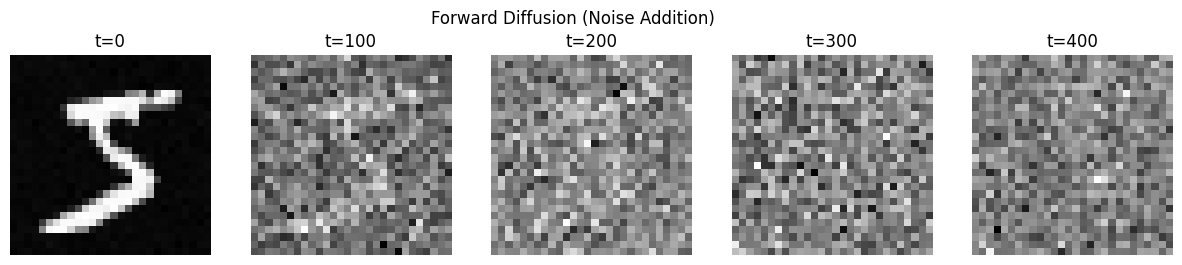

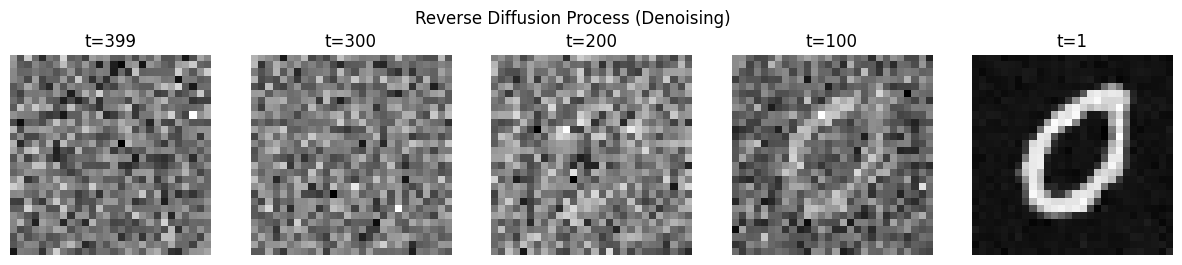

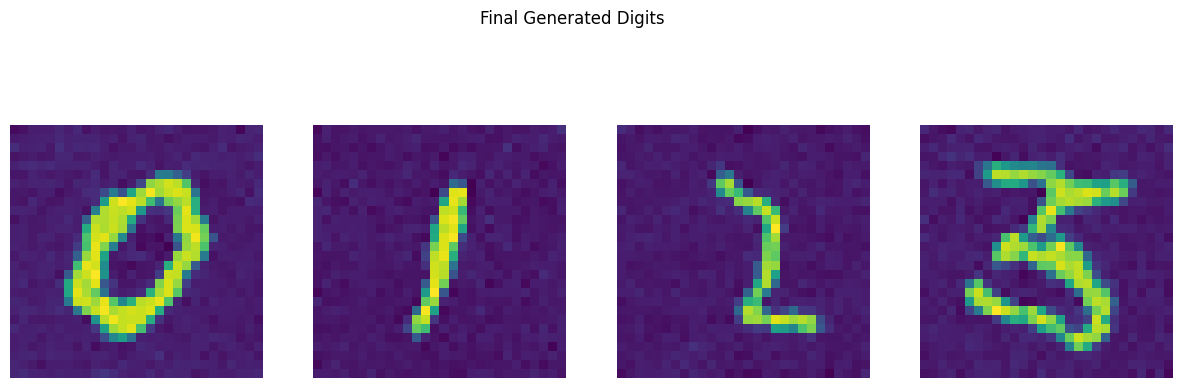

In [ ]:
# Visualizing Noise and Sampling
ddpm.eval()
with torch.no_grad():
    n_sample = 4
    x_gen = torch.randn(n_sample, 1, 28, 28).to(device)
    c_gen = torch.arange(n_sample).to(device) % 10
    c_gen_onehot = F.one_hot(c_gen, n_classes).float()
    context_mask = torch.ones_like(c_gen_onehot).to(device)

    x_store = []
    steps_to_store = [0, n_T//4, n_T//2, 3*n_T//4, n_T-1]

    for i in range(n_T, 0, -1):
        t_tensor = torch.tensor([i / n_T]).to(device).repeat(n_sample)
        z = torch.randn_like(x_gen) if i > 1 else 0

        pred_noise = ddpm(x_gen, c_gen_onehot, t_tensor, context_mask)

        beta_t_val = beta_t[i]
        alpha_t_val = 1 - beta_t_val
        alphabar_t_val = alphabar_t[i]

        noise_coeff = (1 - alpha_t_val) / torch.sqrt(1 - alphabar_t_val)
        x_gen = (1 / torch.sqrt(alpha_t_val)) * (x_gen - noise_coeff * pred_noise) + torch.sqrt(beta_t_val) * z

        if i in steps_to_store or i == 1:
             x_store.append((i, x_gen.cpu().clone()))


    if len(dataset) > 0:
        x_orig = dataset[0][0].unsqueeze(0).to(device)
        cols = 5
        fig, axs = plt.subplots(1, cols, figsize=(15,3))
        ts_to_show = torch.linspace(0, n_T, cols, dtype=torch.long).to(device)

        for i, t_idx in enumerate(ts_to_show):
            t_idx = t_idx.clamp(max=n_T)
            sqrtab = torch.sqrt(alphabar_t)[t_idx].view(-1, 1, 1, 1)
            sqrtmab = torch.sqrt(1 - alphabar_t)[t_idx].view(-1, 1, 1, 1)
            noise = torch.randn_like(x_orig)
            x_noisy = sqrtab * x_orig + sqrtmab * noise
            axs[i].imshow(x_noisy.cpu().squeeze(), cmap='gray')
            axs[i].set_title(f"t={t_idx.item()}")
            axs[i].axis('off')
        plt.suptitle("Forward Diffusion (Noise Addition)")
        plt.show()

        fig, axs = plt.subplots(1, len(x_store), figsize=(15, 3))
        for k, (t_step, img_batch) in enumerate(x_store):
            axs[k].imshow(img_batch[0].squeeze(), cmap='gray')
            axs[k].set_title(f"t={t_step}")
            axs[k].axis('off')
        plt.suptitle("Reverse Diffusion Process (Denoising)")
        plt.show()

    show_images([x.cpu().squeeze() for x in x_gen], title="Final Generated Digits")


## Ответы на вопросы

### Чем диффузионные модели отличаются от GAN?
Диффузионные модели обучаются восстанавливать данные из шума шаг за шагом (итеративно), используя функцию потерь, что стабильнее, чем состязательное обучение в GAN (min-max игра дискриминатора и генератора)

### Почему количество шагов важно для качества?
Большее количество шагов позволяет делать более мелкие и точные изменения при удалении шума, что приводит к лучшему качеству, но требует больше времени на генерацию.

### Какие ещё задачи (помимо генерации картинок) можно решать диффузионными моделями?
Super-resolution, inpainting, генерация аудио, генерация видео, генерация 3D объектов.